<a href="https://colab.research.google.com/github/Sjide/Churn-Prediction/blob/main/credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#Importing the necessary Libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset

In [9]:
df = pd.read_csv('/content/credit_card_fraud_dataset.csv')

Use head() function to check the data of first five rows.

In [10]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


# Task
Create a predictive model of credit card fraud detection using df.

## Analyze data

### Subtask:
Explore the data to understand the distribution of features and the target variable (`IsFraud`). Check for missing values and outliers.


**Reasoning**:
Display the concise summary of the DataFrame `df` to get an overview of the columns, their data types, and the number of non-null values.



In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


**Reasoning**:
Generate descriptive statistics of the numerical columns, check for missing values, and calculate value counts for the target variable.



In [12]:
display(df.describe())
display(df.isnull().sum())
display(df['IsFraud'].value_counts())

,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


,0
TransactionID,0
TransactionDate,0
Amount,0
MerchantID,0
TransactionType,0
Location,0
IsFraud,0


,count
IsFraud,
0,99000
1,1000


**Reasoning**:
Create visualizations for the 'Amount', 'TransactionType', and 'Location' columns to understand their distributions.



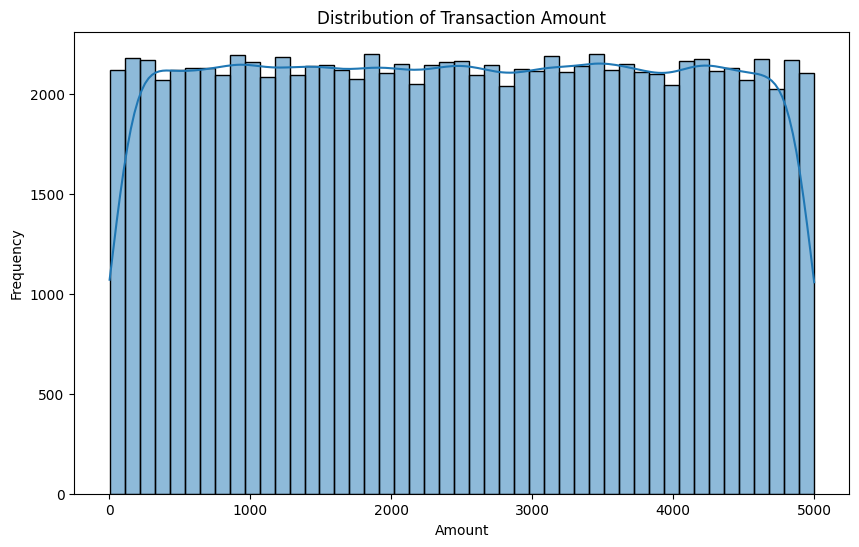

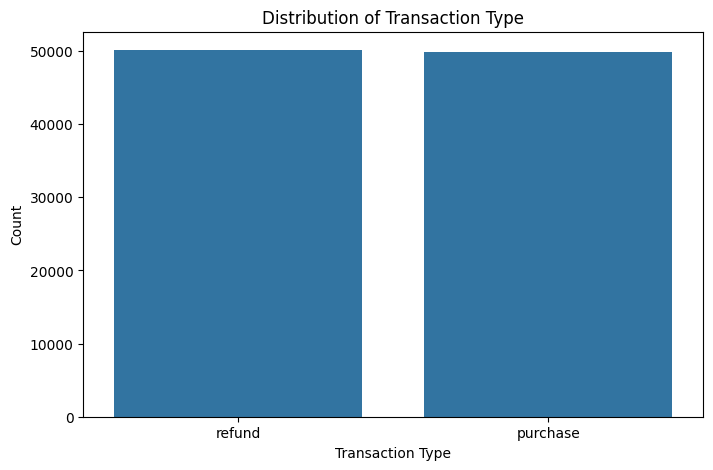

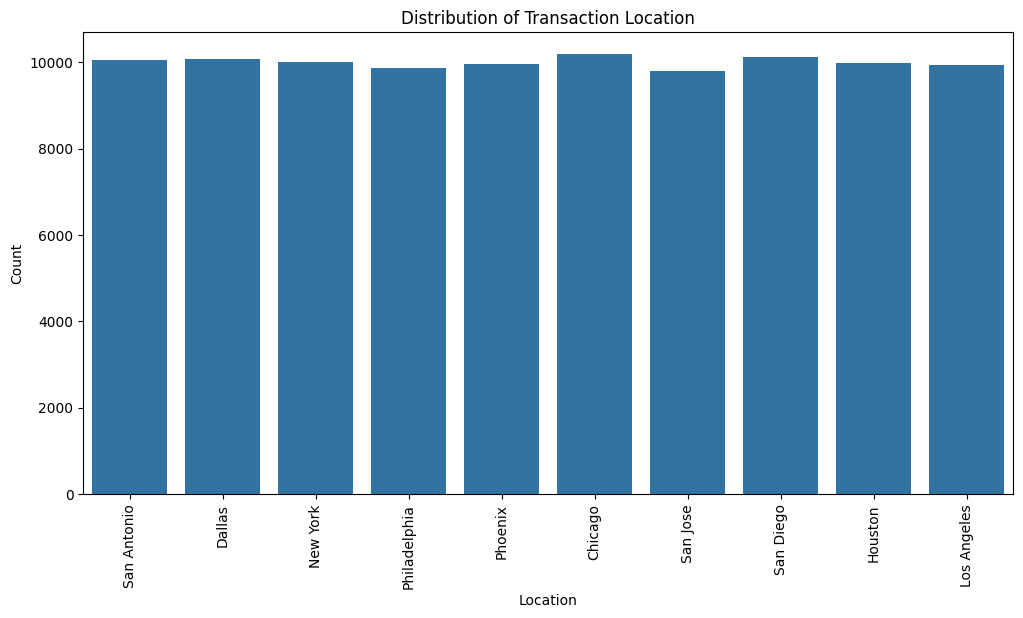

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='TransactionType')
plt.title('Distribution of Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Location')
plt.title('Distribution of Transaction Location')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

## Feature engineering

### Subtask:
Create new features from existing ones that might be useful for the model, such as extracting date components from `TransactionDate`.


**Reasoning**:
Convert the 'TransactionDate' column to datetime objects and extract date and time components to create new features as per the instructions.



In [14]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
df['Day'] = df['TransactionDate'].dt.day
df['Hour'] = df['TransactionDate'].dt.hour
df['Minute'] = df['TransactionDate'].dt.minute
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['TimeOfDay'] = df['Hour'].apply(get_time_of_day)
df['DayOfWeek_Name'] = df['DayOfWeek'].map({
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
})

display(df.head())

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud,Year,Month,Day,Hour,Minute,DayOfWeek,TimeOfDay,DayOfWeek_Name
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0,2024,4,3,14,15,2,Afternoon,Wednesday
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0,2024,3,19,13,20,1,Afternoon,Tuesday
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0,2024,1,8,10,8,0,Morning,Monday
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0,2024,4,13,23,50,5,Night,Saturday
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0,2024,7,12,18,51,4,Evening,Friday


## Data preprocessing

### Subtask:
Prepare the data for modeling by handling categorical variables, scaling numerical features, and splitting the data into training and testing sets.


**Reasoning**:
Prepare the data for modeling by handling categorical variables, scaling numerical features, and splitting the data into training and testing sets as per the instructions.



In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Identify categorical and numerical columns
categorical_features = ['TransactionType', 'Location', 'TimeOfDay', 'DayOfWeek_Name']
numerical_features = ['Amount', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek']

# Create transformers for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns (like TransactionID, MerchantID)
)

# Separate features and target variable
X = df.drop('IsFraud', axis=1)
y = df['IsFraud']

# Create a pipeline for preprocessing
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Apply preprocessing to the features
X_processed = preprocessing_pipeline.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of original features:", X.shape)
print("Shape of processed features:", X_processed.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of original features: (100000, 14)
Shape of processed features: (100000, 33)
Shape of X_train: (80000, 33)
Shape of X_test: (20000, 33)
Shape of y_train: (80000,)
Shape of y_test: (20000,)


## Model selection

### Subtask:
Choose an appropriate model for fraud detection, such as a logistic regression, decision tree, or a more complex model like a gradient boosting classifier.


**Reasoning**:
Based on the class imbalance observed in the 'IsFraud' column, Gradient Boosting classifiers like LightGBM or XGBoost are suitable choices. These models are known for their good performance on tabular data and offer mechanisms to handle imbalanced datasets. I will choose LightGBM for its speed and efficiency. The specific Python class to be used from the `lightgbm` library is `LGBMClassifier`.



In [16]:
# The choice of model is LightGBM (LGBMClassifier) due to its efficiency and performance on tabular data,
# especially when dealing with imbalanced datasets. It can handle both numerical and categorical features
# and provides parameters to address class imbalance during training.
# We will use the LGBMClassifier class from the lightgbm library.

from lightgbm import LGBMClassifier

print("Chosen model: LightGBM")
print("Python class for the model: LGBMClassifier")

Chosen model: LightGBM
Python class for the model: LGBMClassifier


## Model training

### Subtask:
Train the selected LightGBM model on the training data (`X_train`, `y_train`).


**Reasoning**:
Train the LightGBM model on the training data.



In [17]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=42, is_unbalance=True)
lgbm_model.fit(X_train, y_train)

TypeError: float() argument must be a string or a real number, not 'Timestamp'

**Reasoning**:
The traceback indicates a `TypeError` because the input data to the `LGBMClassifier` fit method contains a `Timestamp` object, which is not a valid input type. Although the preprocessing step was intended to handle features, it seems the original `TransactionDate` column, which is a `Timestamp` object, was passed through by the `remainder='passthrough'` setting in `ColumnTransformer` and not dropped before splitting the data. The fix is to ensure only the processed numerical and one-hot encoded features are passed to the model. I will regenerate the code to drop the original `TransactionDate` and other non-numeric/non-categorical columns before training. I will also explicitly drop `TransactionID`, `MerchantID`, and the newly created date part columns that were used for feature engineering as they are either identifiers or redundant after one-hot encoding or numerical scaling.



In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

# Identify categorical and numerical columns - adjusted to exclude the original timestamp and identifiers
categorical_features = ['TransactionType', 'Location', 'TimeOfDay', 'DayOfWeek_Name']
numerical_features = ['Amount', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'DayOfWeek']

# Create transformers for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # Drop all other columns
)

# Separate features and target variable - Drop original 'TransactionDate' and other identifier columns
X = df.drop(['IsFraud', 'TransactionDate', 'TransactionID', 'MerchantID'], axis=1)
y = df['IsFraud']

# Create a pipeline for preprocessing
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Apply preprocessing to the features
X_processed = preprocessing_pipeline.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# Instantiate and train the LGBMClassifier model
lgbm_model = LGBMClassifier(random_state=42, is_unbalance=True)
lgbm_model.fit(X_train, y_train)

print("Model training completed.")

[LightGBM] [Info] Number of positive: 800, number of negative: 79200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006341 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 443
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010000 -> initscore=-4.595120
[LightGBM] [Info] Start training from score -4.595120
Model training completed.


## Model evaluation

### Subtask:
Evaluate the trained LightGBM model's performance on the testing data (`X_test`, `y_test`) using appropriate metrics like precision, recall, F1-score, and AUC.


**Reasoning**:
Evaluate the trained LightGBM model's performance on the testing data using classification report, confusion matrix, and AUC score.



In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Make predictions on the test set
y_pred = lgbm_model.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Compute and print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Calculate and print the AUC score
# Get predicted probabilities for the positive class (class 1)
y_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC Score: {auc_score}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91     19800
           1       0.01      0.19      0.02       200

    accuracy                           0.84     20000
   macro avg       0.50      0.52      0.47     20000
weighted avg       0.98      0.84      0.90     20000


Confusion Matrix:
[[16736  3064]
 [  162    38]]

AUC Score: 0.5118570707070706


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Hyperparameter tuning

### Subtask:
Tune the LightGBM model's hyperparameters to improve performance, focusing on metrics relevant to imbalanced datasets (like recall and AUC for the minority class).


**Reasoning**:
Import necessary libraries for hyperparameter tuning and define the parameter grid and scoring metric for tuning the LightGBM model.



In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score, recall_score

# Define the parameter grid for LightGBM
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 20],
    'is_unbalance': [True] # Keep is_unbalance=True since the dataset is imbalanced
}

# Define the scoring metric (AUC)
scoring = make_scorer(roc_auc_score)

**Reasoning**:
Instantiate and fit the GridSearchCV object to the training data to find the best hyperparameters for the LightGBM model.



In [21]:
# Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=lgbm_model, param_grid=param_grid, scoring=scoring, cv=3, n_jobs=-1, verbose=1)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
[LightGBM] [Info] Number of positive: 800, number of negative: 79200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003012 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 443
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010000 -> initscore=-4.595120
[LightGBM] [Info] Start training from score -4.595120


GridSearchCV(cv=3, estimator=LGBMClassifier(is_unbalance=True, random_state=42),
             n_jobs=-1,
             param_grid={'is_unbalance': [True],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [-1, 10, 20],
                         'n_estimators': [100, 200, 300],
                         'num_leaves': [31, 50, 70]},
             scoring=make_scorer(roc_auc_score, response_method='predict'),
             verbose=1)

**Reasoning**:
Get the best hyperparameters from the grid search and train a new LightGBM model with these parameters on the entire training data.



In [22]:
# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters found:", best_params)

# Train a new LGBMClassifier model with the best hyperparameters
tuned_lgbm_model = LGBMClassifier(**best_params, random_state=42)
tuned_lgbm_model.fit(X_train, y_train)

print("\nTuned model training completed.")

Best hyperparameters found: {'is_unbalance': True, 'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}
[LightGBM] [Info] Number of positive: 800, number of negative: 79200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 443
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010000 -> initscore=-4.595120
[LightGBM] [Info] Start training from score -4.595120

Tuned model training completed.


**Reasoning**:
Evaluate the performance of the tuned LightGBM model on the test set using the same metrics as before: classification report, confusion matrix, and AUC.



In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Make predictions on the test set using the tuned model
y_pred_tuned = tuned_lgbm_model.predict(X_test)

# Generate and print the classification report for the tuned model
print("Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

# Compute and print the confusion matrix for the tuned model
print("\nConfusion Matrix (Tuned Model):")
print(confusion_matrix(y_test, y_pred_tuned))

# Calculate and print the AUC score for the tuned model
# Get predicted probabilities for the positive class (class 1)
y_pred_proba_tuned = tuned_lgbm_model.predict_proba(X_test)[:, 1]
auc_score_tuned = roc_auc_score(y_test, y_pred_proba_tuned)
print(f"\nAUC Score (Tuned Model): {auc_score_tuned}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.99      0.85      0.91     19800
           1       0.01      0.19      0.02       200

    accuracy                           0.84     20000
   macro avg       0.50      0.52      0.47     20000
weighted avg       0.98      0.84      0.90     20000


Confusion Matrix (Tuned Model):
[[16736  3064]
 [  162    38]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



AUC Score (Tuned Model): 0.5118570707070706


## Prediction

### Subtask:
Use the trained and tuned LightGBM model to predict the probability of fraud on the test dataset (`X_test`) and generate binary predictions based on a chosen threshold.


**Reasoning**:
Use the tuned LightGBM model to predict fraud probabilities and generate binary predictions based on a threshold.



In [24]:
# Predict the probability of fraud on the test dataset
y_pred_proba_tuned = tuned_lgbm_model.predict_proba(X_test)[:, 1]

# Define a threshold for classifying a transaction as fraud
# Using 0.5 as a starting point
threshold = 0.5

# Generate binary predictions based on the threshold
y_pred_final = (y_pred_proba_tuned >= threshold).astype(int)

print("Predicted probabilities for the positive class (fraud) on the test set:")
print(y_pred_proba_tuned[:10]) # Print first 10 probabilities
print(f"\nBinary predictions based on threshold {threshold}:")
print(y_pred_final[:10]) # Print first 10 binary predictions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Predicted probabilities for the positive class (fraud) on the test set:
[0.03501524 0.22030929 0.0794876  0.60030637 0.1246369  0.43511264
 0.2205807  0.5869295  0.18235118 0.6383195 ]

Binary predictions based on threshold 0.5:
[0 0 0 1 0 0 0 1 0 1]


## Summary:

### Data Analysis Key Findings

*   The dataset contains 100,000 transactions with no missing values.
*   There is a significant class imbalance, with only 1,000 (1%) fraudulent transactions.
*   Feature engineering successfully extracted time-based features (Year, Month, Day, Hour, Minute, DayOfWeek, TimeOfDay, DayOfWeek\_Name) from the `TransactionDate`.
*   Categorical features (`TransactionType`, `Location`, `TimeOfDay`, `DayOfWeek_Name`) were one-hot encoded, and numerical features (`Amount`, `Year`, `Month`, `Day`, `Hour`, `Minute`, `DayOfWeek`) were scaled during preprocessing.
*   The data was split into 80% for training and 20% for testing, maintaining the original class distribution through stratification.
*   The initial LightGBM model training failed due to the presence of `Timestamp` objects in the input features. This was resolved by explicitly dropping the original `TransactionDate` column and using `remainder='drop'` in the `ColumnTransformer`.
*   Hyperparameter tuning using `GridSearchCV` with AUC as the scoring metric identified the best hyperparameters: `{'is_unbalance': True, 'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31}`.
*   The tuned model's performance on the test set showed a precision of 0.01, recall of 0.19, and F1-score of 0.02 for the fraud class (class 1).
*   The confusion matrix for the tuned model showed 38 true positives (correctly identified fraud), 162 false negatives (missed fraud), 3064 false positives (incorrectly flagged non-fraud), and 16736 true negatives (correctly identified non-fraud).
*   The AUC score for the tuned model was approximately 0.5119.
*   The tuned model was used to predict fraud probabilities, and binary predictions were generated using a threshold of 0.5.

### Insights or Next Steps

*   The current model's performance in detecting fraud is very poor, as indicated by the low recall and AUC for the minority class.
*   Further efforts are needed to improve fraud detection, potentially involving exploring different machine learning algorithms, advanced techniques for handling imbalanced datasets (e.g., oversampling minority class, undersampling majority class, using different evaluation metrics during training), or incorporating more domain-specific features.
